In [10]:
# Step 1: Import libraries

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [11]:
data=pd.read_csv("student-por.csv")
data

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
644,MS,F,19,R,GT3,T,2,3,services,other,...,5,4,2,1,2,5,4,10,11,10
645,MS,F,18,U,LE3,T,3,1,teacher,services,...,4,3,4,1,1,1,4,15,15,16
646,MS,F,18,U,GT3,T,1,1,other,other,...,1,1,1,1,1,5,6,11,12,9
647,MS,M,17,U,LE3,T,3,1,services,services,...,2,4,5,3,4,2,6,10,10,10


In [12]:
# Step 3: Select only two columns

data = data[["G2", "G3"]]
data

,G2,G3
0,11,11
1,11,11
2,13,12
3,14,14
4,13,13
...,...,...
644,11,10
645,15,16
646,12,9
647,10,10


In [13]:
# Step 4: Check missing values

data.isnull().sum()

,0
G2,0
G3,0


In [15]:
# Step 5: Convert G3 into Pass / Fail

data["Pass"] = (data["G3"] >= 10)

data

/tmp/ipykernel_823/3617061824.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["Pass"] = (data["G3"] >= 10)


,G2,G3,Pass
0,11,11,True
1,11,11,True
2,13,12,True
3,14,14,True
4,13,13,True
...,...,...,...
644,11,10,True
645,15,16,True
646,12,9,False
647,10,10,True


In [16]:
# Step 6: Input and target

x = data[["G2"]]
y = data["Pass"]

print(x)
print(y)

     G2
0    11
1    11
2    13
3    14
4    13
..   ..
644  11
645  15
646  12
647  10
648  11

[649 rows x 1 columns]
0       True
1       True
2       True
3       True
4       True
       ...  
644     True
645     True
646    False
647     True
648     True
Name: Pass, Length: 649, dtype: bool


In [17]:
# Step 7: Split dataset

x_train, x_test, y_train, y_test = train_test_split( x,y,test_size=0.20,random_state=42,stratify=y)

In [18]:
# Step 8: Create model

model = LogisticRegression()

model.fit(x_train, y_train)

LogisticRegression()

In [19]:
# Step 9: Prediction

y_pred = model.predict(x_test)

print(y_pred)

[ True  True  True  True  True False False  True  True  True False  True
 False  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True False  True  True  True  True  True  True False
  True  True  True  True  True  True  True  True  True  True False  True
 False False  True False  True  True  True  True  True  True  True  True
  True False  True  True  True  True  True False  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True False  True  True  True  True False
  True  True  True  True  True  True  True  True  True  True  True  True
  True False  True  True  True  True  True  True  True  True]


In [20]:
# Step 10: Accuracy

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy * 100, 2), "%")

Accuracy: 94.62 %


In [21]:
# Step 11: Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[ 14   6]
 [  1 109]]


In [22]:
# Step 12: Classification Report

print(classification_report(y_test,y_pred,target_names=["Fail", "Pass"]))

              precision    recall  f1-score   support

        Fail       0.93      0.70      0.80        20
        Pass       0.95      0.99      0.97       110

    accuracy                           0.95       130
   macro avg       0.94      0.85      0.88       130
weighted avg       0.95      0.95      0.94       130



In [24]:
# Step 14: User input

g2 = float(input("Enter student's G2 grade: "))

prediction = model.predict([[g2]])

if prediction[0] == 1:
    print("\nRESULT : PASS")
else:
    print("\nRESULT : FAIL")

Enter student's G2 grade: 15

RESULT : PASS


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


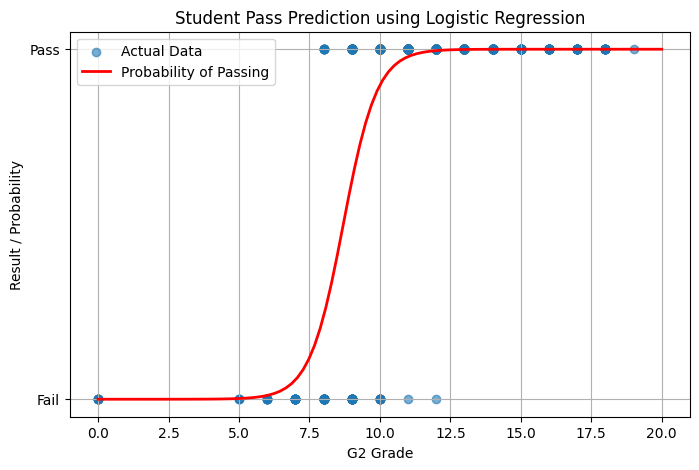

In [27]:
# Step 13: Scatter plot with Logistic Regression curve
import numpy as np
import pandas as pd

plt.figure(figsize=(8, 5))

# Plot the actual student data points
plt.scatter(
    data["G2"],
    data["Pass"],
    alpha=0.6,
    label="Actual Data"
)

# Generate sequence of G2 values to plot the smooth sigmoid curve

x_lines_arr = np.linspace(0, 20, 100).reshape(-1, 1)

# Convert to DataFrame with matching feature name to avoid warnings

x_lines = pd.DataFrame(x_lines_arr, columns=["G2"])

# Predict probabilities (index 1 is the probability of class True/Pass)

y_prob = model.predict_proba(x_lines)[:, 1]

# Plot the logistic regression decision line

plt.plot(x_lines, y_prob, color="red", linewidth=2, label="Probability of Passing")

plt.xlabel("G2 Grade")
plt.ylabel("Result / Probability")
plt.yticks([0, 1], ["Fail", "Pass"])
plt.title("Student Pass Prediction using Logistic Regression")
plt.legend()
plt.grid(True)
plt.show()